✅ Paths configured successfully!
Project Root: C:\Users\kecab\nairobi-crime-esta\notebooks
Raw Data Dir: C:\Users\kecab\nairobi-crime-esta\notebooks\data\raw


C:\Users\kecab\AppData\Local\Temp\ipykernel_21808\2249379345.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mock_data, x='ward', y='incidents', palette='viridis')


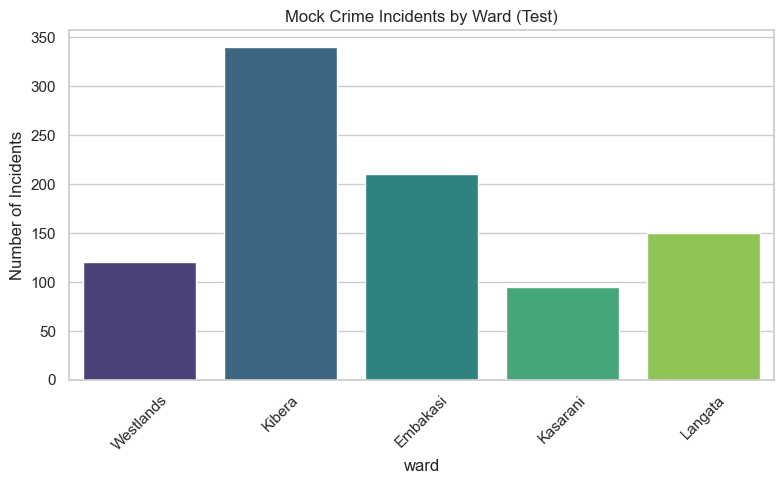

✅ Visualization test passed!


In [2]:
import os
from pathlib import Path

# 1. Define robust project paths
# This goes up one level from 'notebooks/' to the main 'nairobi-crime-esta/' folder
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("✅ Paths configured successfully!")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Raw Data Dir: {RAW_DATA_DIR}")

# 2. Create a tiny mock dataset to test our libraries
mock_data = pd.DataFrame({
    'ward': ['Westlands', 'Kibera', 'Embakasi', 'Kasarani', 'Langata'],
    'incidents': [120, 340, 210, 95, 150],
    'latitude': [-1.267, -1.313, -1.319, -1.221, -1.337],
    'longitude': [36.808, 36.788, 36.898, 36.898, 36.783]
})

# 3. Quick visualization test
plt.figure(figsize=(8, 5))
sns.barplot(data=mock_data, x='ward', y='incidents', palette='viridis')
plt.title('Mock Crime Incidents by Ward (Test)')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Visualization test passed!")

In [1]:
import sys
from pathlib import Path

# 1. Find the absolute path to the main project folder
# We know we are currently in: ...\notebooks\Spatial
current_notebook_dir = Path.cwd()

# Go up TWO levels to get to the main 'nairobi-crime-esta' folder
project_root = current_notebook_dir.parent.parent
src_path = project_root / "src"

print(f"🔍 Looking for src folder at: {src_path}")

# Check if the folder and file actually exist
if src_path.exists():
    print("✅ src folder found!")
    if (src_path / "data_processing.py").exists():
        print("✅ data_processing.py found!")
    else:
        print("❌ data_processing.py NOT found. Check for a hidden .txt extension!")
else:
    print("❌ src folder NOT found at this path.")

# 2. Add the src folder to Python's path
sys.path.append(str(src_path))

# 3. Import the function
try:
    from data_processing import generate_mock_nairobi_data
    print("\n🎉 SUCCESS! Modular function imported successfully.")
    
    # Test it
    mock_nairobi_data = generate_mock_nairobi_data(seed=42)
    display(mock_nairobi_data.head())
    
except ModuleNotFoundError as e:
    print(f"\n❌ Import failed: {e}")
    print("Please check Step 1 (the hidden .txt extension) and try again.")

🔍 Looking for src folder at: C:\Users\kecab\nairobi-crime-esta\src
✅ src folder found!
✅ data_processing.py found!

🎉 SUCCESS! Modular function imported successfully.


,sub_county,population,crime_incidents,latitude,longitude
0,Westlands,221958,393,-1.265214,36.865506
1,Dagoretti North,246867,541,-1.352568,36.767279
2,Dagoretti South,231932,463,-1.262793,36.825619
3,Langata,359178,435,-1.332716,36.833079
4,Kibra,219879,241,-1.349592,36.731759


# 01. Exploratory Data Analysis (EDA)
**Project:** Nairobi Crime ESTA
**Goal:** Clean, explore, and visualize the raw crime microdata.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# Set a nice visualization style
sns.set_theme(style="whitegrid")

print("All core libraries imported successfully!")

All core libraries imported successfully!


✅ Mock Sub-County Data Created:


,sub_county,population,crime_incidents,latitude,longitude
0,Westlands,221958,393,-1.265214,36.865506
1,Dagoretti North,246867,541,-1.352568,36.767279
2,Dagoretti South,231932,463,-1.262793,36.825619
3,Langata,359178,435,-1.332716,36.833079
4,Kibra,219879,241,-1.349592,36.731759


C:\Users\kecab\AppData\Local\Temp\ipykernel_21808\2935097602.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mock_nairobi_data, x='sub_county', y='crime_incidents', palette='Reds_r')


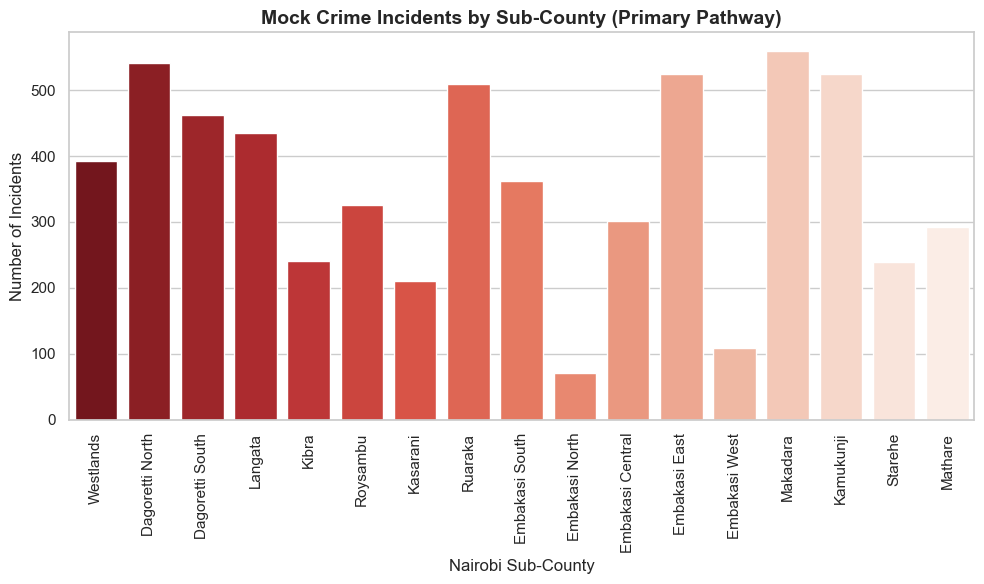

✅ Successfully generated data for 17 sub-counties!


In [3]:
# 1. Define the 17 Sub-Counties (Constituencies) of Nairobi
sub_counties = [
    'Westlands', 'Dagoretti North', 'Dagoretti South', 'Langata', 'Kibra',
    'Roysambu', 'Kasarani', 'Ruaraka', 'Embakasi South', 'Embakasi North',
    'Embakasi Central', 'Embakasi East', 'Embakasi West', 'Makadara',
    'Kamukunji', 'Starehe', 'Mathare'
]

# 2. Generate mock data for these 17 sub-counties
# We use a random seed so your numbers stay consistent every time you run it
np.random.seed(42)

mock_nairobi_data = pd.DataFrame({
    'sub_county': sub_counties,
    'population': np.random.randint(100000, 450000, size=17), # Mock population
    'crime_incidents': np.random.randint(50, 600, size=17),   # Mock crime count
    'latitude': np.random.uniform(-1.36, -1.20, size=17),     # Mock centroid latitudes
    'longitude': np.random.uniform(36.68, 36.96, size=17)     # Mock centroid longitudes
})

# Display the first few rows to verify
print("✅ Mock Sub-County Data Created:")
display(mock_nairobi_data.head())

# 3. Visualize the mock crime data
plt.figure(figsize=(10, 6))
# We use 'Reds_r' palette so darker red means more crime
sns.barplot(data=mock_nairobi_data, x='sub_county', y='crime_incidents', palette='Reds_r')

plt.title('Mock Crime Incidents by Sub-County (Primary Pathway)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Incidents')
plt.xlabel('Nairobi Sub-County')
plt.xticks(rotation=90) # Rotate labels 90 degrees so all 17 names fit
plt.tight_layout()
plt.show()

print(f"✅ Successfully generated data for {len(mock_nairobi_data)} sub-counties!")

In [6]:
# 1. Save the mock data to the 'data/raw/' folder
# We use the RAW_DATA_DIR path we defined earlier
file_path = RAW_DATA_DIR / "nairobi_subcounty_mock_data.csv"
mock_nairobi_data.to_csv(file_path, index=False)
print(f"✅ Saved mock data to: {file_path}")

# 2. Read it back in to prove the pipeline works
df = pd.read_csv(file_path)
print(f"✅ Loaded data successfully! Shape: {df.shape} (Rows, Columns)")

# 3. Basic EDA: Summary Statistics
print("\n--- Summary Statistics ---")
display(df.describe())

# 4. Basic EDA: Check for missing values
print("\n--- Missing Values Check ---")
display(df.isnull().sum())

✅ Saved mock data to: C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial\data\raw\nairobi_subcounty_mock_data.csv
✅ Loaded data successfully! Shape: (17, 5) (Rows, Columns)

--- Summary Statistics ---


,population,crime_incidents,latitude,longitude
count,17.000000,17.000000,17.000000,17.000000
mean,260034.588235,359.000000,-1.288929,36.822302
std,84072.258630,152.834469,0.053770,0.087408
min,141090.000000,71.000000,-1.354498,36.692664
25%,210268.000000,241.000000,-1.340474,36.755978
50%,237337.000000,363.000000,-1.289576,36.825619
75%,307892.000000,509.000000,-1.250523,36.897037
max,429365.000000,560.000000,-1.205499,36.951484



--- Missing Values Check ---


sub_county         0
population         0
crime_incidents    0
latitude           0
longitude          0
dtype: int64

In [5]:
import os
from pathlib import Path

# 1. Foolproof way to find the project root
current_dir = Path.cwd()

# If we are inside the 'notebooks' folder, go up one level to the main project folder
if current_dir.name == 'notebooks':
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# 2. Define the data directories
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

# 3. CRITICAL: Create these folders if they don't exist yet!
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths configured successfully!")
print(f"Project Root: {PROJECT_ROOT}")
print(f"Raw Data Dir: {RAW_DATA_DIR}")

✅ Paths configured successfully!
Project Root: C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial
Raw Data Dir: C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial\data\raw


In [1]:
import folium
from folium import CircleMarker

# 1. Set the center of the map (Nairobi's approximate center coordinates)
nairobi_center = [-1.2921, 36.8219]

# 2. Create the base interactive map
# zoom_start=11 is perfect for viewing a whole city
m = folium.Map(location=nairobi_center, zoom_start=11, tiles='OpenStreetMap')

# 3. Add a circle marker for each sub-county
for idx, row in mock_nairobi_data.iterrows():
    # The radius of the circle represents the number of crime incidents
    # We divide by 10 just so the circles don't overlap too much on the map
    circle_radius = row['crime_incidents'] / 10 
    
    # Create the popup text that appears when you click the circle
    popup_text = f"""
    <b>{row['sub_county']}</b><br>
    Crime Incidents: {row['crime_incidents']}<br>
    Population: {row['population']:,}
    """
    
    # Add the circle to the map
    CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=circle_radius,
        popup=popup_text,
        color='darkred',
        fill=True,
        fill_color='red',
        fill_opacity=0.7
    ).add_to(m)

# 4. Display the map
m

NameError: name 'mock_nairobi_data' is not defined

In [2]:
# ==========================================
# MASTER CELL: Imports, Data, and Map
# ==========================================

# 1. Import everything we need
import pandas as pd
import numpy as np
import folium
from folium import CircleMarker

# 2. Recreate the 17 Sub-Counties Mock Data
sub_counties = [
    'Westlands', 'Dagoretti North', 'Dagoretti South', 'Langata', 'Kibra',
    'Roysambu', 'Kasarani', 'Ruaraka', 'Embakasi South', 'Embakasi North',
    'Embakasi Central', 'Embakasi East', 'Embakasi West', 'Makadara',
    'Kamukunji', 'Starehe', 'Mathare'
]

np.random.seed(42)
mock_nairobi_data = pd.DataFrame({
    'sub_county': sub_counties,
    'population': np.random.randint(100000, 450000, size=17),
    'crime_incidents': np.random.randint(50, 600, size=17),
    'latitude': np.random.uniform(-1.36, -1.20, size=17),
    'longitude': np.random.uniform(36.68, 36.96, size=17)
})

print(f"✅ Data created for {len(mock_nairobi_data)} sub-counties.")

# 3. Create and display the map
nairobi_center = [-1.2921, 36.8219]
m = folium.Map(location=nairobi_center, zoom_start=11, tiles='OpenStreetMap')

for idx, row in mock_nairobi_data.iterrows():
    popup_text = f"<b>{row['sub_county']}</b><br>Incidents: {row['crime_incidents']}"
    
    CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['crime_incidents'] / 15, 
        popup=popup_text,
        color='darkred',
        fill=True,
        fill_color='red',
        fill_opacity=0.6
    ).add_to(m)

print("✅ Map generated! Scroll down to see it.")
m

✅ Data created for 17 sub-counties.
✅ Map generated! Scroll down to see it.


✅ High-resolution map saved to: C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial\outputs\nairobi_crime_map.png


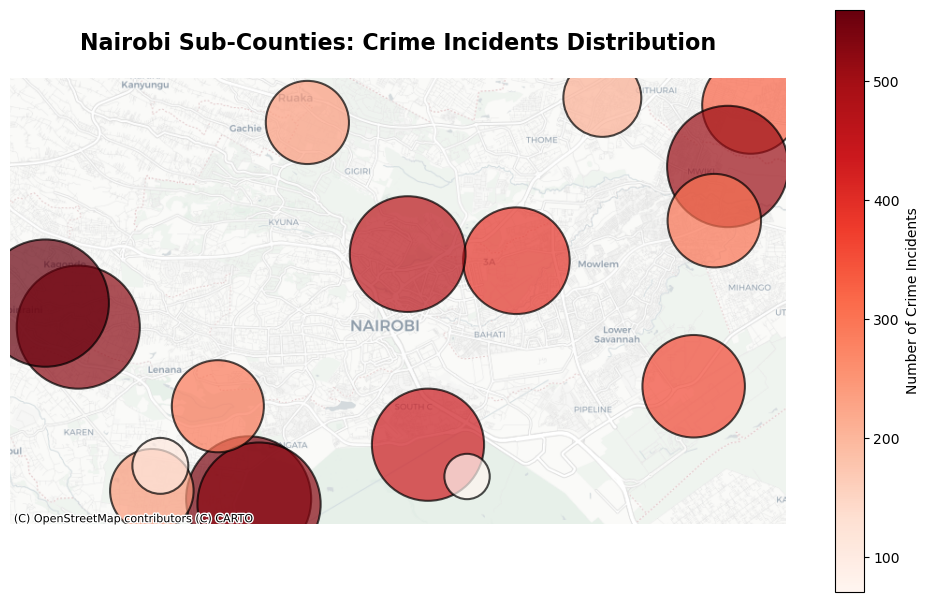

In [5]:
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from pathlib import Path

# 0. Foolproof path definition (in case it was forgotten)
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir

# 1. Convert our pandas DataFrame into a GeoDataFrame
gdf = gpd.GeoDataFrame(
    mock_nairobi_data, 
    geometry=gpd.points_from_xy(mock_nairobi_data.longitude, mock_nairobi_data.latitude),
    crs="EPSG:4326"
)

# 2. Reproject to Web Mercator (required for internet map tiles)
gdf = gdf.to_crs(epsg=3857)

# 3. Create the publication-ready static map
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column='crime_incidents', 
    cmap='Reds', 
    markersize=gdf['crime_incidents'] * 15, 
    alpha=0.7, 
    edgecolor='black', 
    linewidth=1.5, 
    ax=ax, 
    legend=True,
    legend_kwds={'label': "Number of Crime Incidents", 'shrink': 0.6}
)

# 4. Add the real basemap of Nairobi
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# 5. Add titles and formatting
ax.set_title("Nairobi Sub-Counties: Crime Incidents Distribution", fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off() 

# 6. SAVE THE MAP AS A HIGH-RESOLUTION IMAGE
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True) # Creates the folder if it doesn't exist

file_path = OUTPUT_DIR / "nairobi_crime_map.png"

# CRITICAL: Save BEFORE calling plt.show()
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"✅ High-resolution map saved to: {file_path}")

plt.tight_layout()
plt.show()

In [6]:
import os
from pathlib import Path

# 1. Find exactly where Jupyter thinks it is right now
current_dir = Path.cwd()
print(f"📍 Current Jupyter Directory: {current_dir}")

# 2. Calculate the Project Root
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
print(f"📍 Project Root Directory: {PROJECT_ROOT}")

# 3. Define the output path
OUTPUT_DIR = PROJECT_ROOT / "outputs"
file_path = OUTPUT_DIR / "nairobi_crime_map.png"

# 4. Check if the file exists and print the EXACT absolute path
if file_path.exists():
    print(f"\n🎉 SUCCESS! The file is located exactly here:")
    print(f"👉 {file_path.resolve()}")
    print("\n💡 TIP: You can highlight that path, copy it (Ctrl+C), and paste it directly into the address bar at the top of your Windows File Explorer!")
else:
    print(f"\n❌ File not found at: {file_path.resolve()}")
    print("Let's see what folders actually exist in the Project Root:")
    print([f.name for f in PROJECT_ROOT.iterdir() if f.is_dir()])

📍 Current Jupyter Directory: C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial
📍 Project Root Directory: C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial

🎉 SUCCESS! The file is located exactly here:
👉 C:\Users\kecab\nairobi-crime-esta\notebooks\Spatial\outputs\nairobi_crime_map.png

💡 TIP: You can highlight that path, copy it (Ctrl+C), and paste it directly into the address bar at the top of your Windows File Explorer!
